In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "surat_uncleaned.csv",
    engine="python"
)

In [3]:
df.head()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac


In [4]:
df.shape

(4525, 11)

In [5]:
df.columns

Index(['property_name', 'areaWithType', 'square_feet', 'transaction', 'status',
       'floor', 'furnishing', 'facing', 'description', 'price_per_sqft',
       'price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   property_name   4525 non-null   object
 1   areaWithType    4525 non-null   object
 2   square_feet     4525 non-null   object
 3   transaction     4421 non-null   object
 4   status          4524 non-null   object
 5   floor           4480 non-null   object
 6   furnishing      4185 non-null   object
 7   facing          3936 non-null   object
 8   description     3154 non-null   object
 9   price_per_sqft  4157 non-null   object
 10  price           4525 non-null   object
dtypes: object(11)
memory usage: 389.0+ KB


In [7]:
df.isnull().sum()

property_name        0
areaWithType         0
square_feet          0
transaction        104
status               1
floor               45
furnishing         340
facing             589
description       1371
price_per_sqft     368
price                0
dtype: int64

In [9]:
df.columns = df.columns.str.lower().str.strip()

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
def clean_price(x):

    x = str(x).replace('₹', '').strip()

    if 'Cr' in x:
        return float(x.replace('Cr', '').strip()) * 100

    elif 'Lac' in x:
        return float(x.replace('Lac', '').strip())

    return np.nan


df['price_cleaned'] = df['price'].apply(clean_price)

In [12]:
df['sqft_cleaned'] = (
    df['square_feet']
    .str.replace('sqft', '', regex=False)
    .str.strip()
)

df['sqft_cleaned'] = pd.to_numeric(
    df['sqft_cleaned'],
    errors='coerce'
)

In [13]:
df['bhk_type'] = df['property_name'].str.extract(r'(\d+\s*BHK)')

In [14]:
df.dropna(
    subset=['price_cleaned', 'sqft_cleaned'],
    inplace=True
)

In [15]:
df = df[df['price_cleaned'] < 1000]

In [16]:
df.describe()

,price_cleaned,sqft_cleaned
count,4036.000000,4036.000000
mean,106.228320,1823.913528
std,110.645217,5455.588305
min,1.000000,3.000000
25%,42.000000,889.750000
50%,70.000000,1300.000000
75%,128.250000,2060.250000
max,900.000000,315200.000000


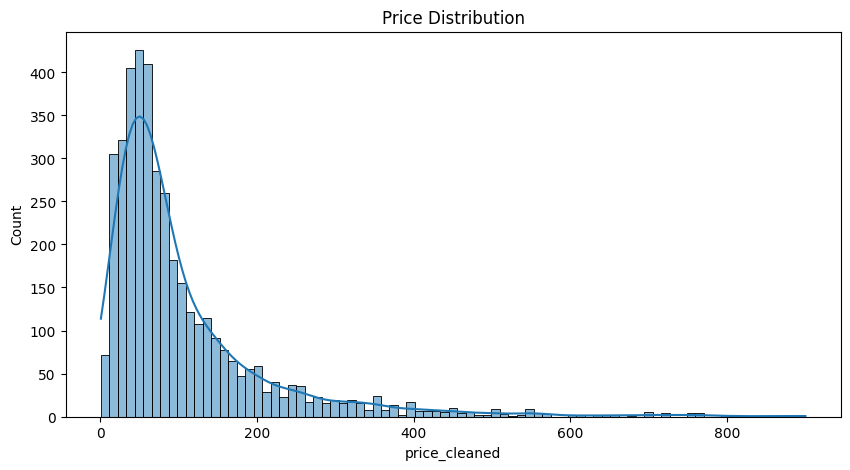

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['price_cleaned'],
    kde=True
)

plt.title("Price Distribution")
plt.show()

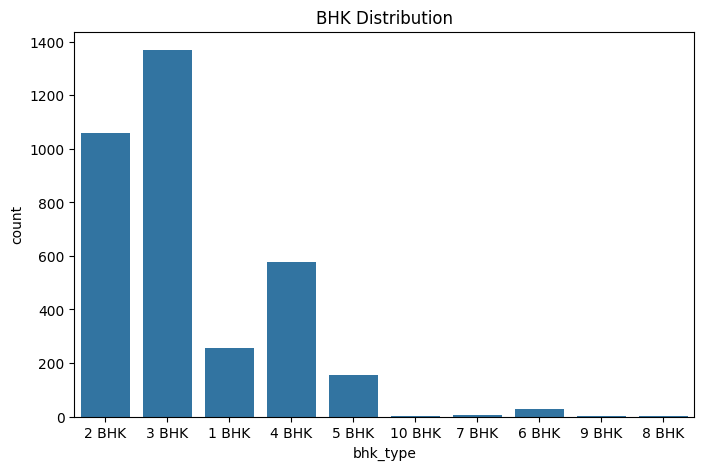

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='bhk_type',
    data=df
)

plt.title("BHK Distribution")
plt.show()

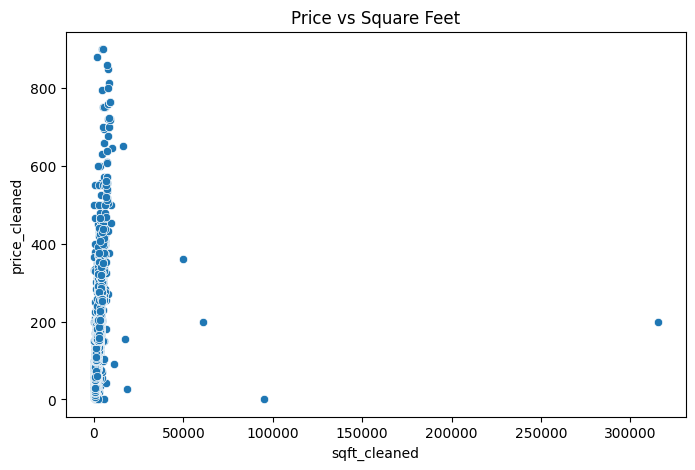

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sqft_cleaned',
    y='price_cleaned',
    data=df
)

plt.title("Price vs Square Feet")
plt.show()

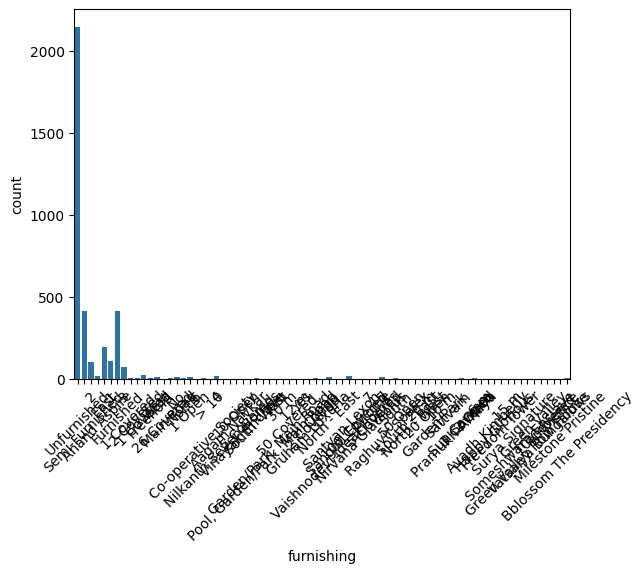

In [20]:
sns.countplot(
    x='furnishing',
    data=df
)

plt.xticks(rotation=45)
plt.show()

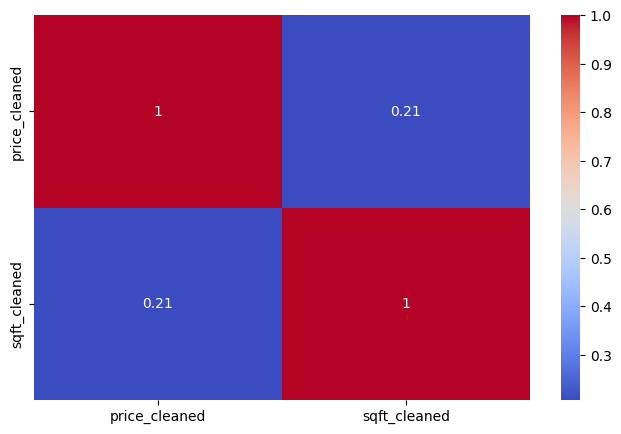

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [22]:
df.to_excel(
    "surat_cleaned_final.xlsx",
    index=False
)

In [1]:
git init
git add .
git commit -m "first upload"
git branch -M main
git remote add origin <github-repo-url>
git push -u origin main

SyntaxError: invalid syntax (2299931052.py, line 1)